# Word2Vec 학습 및 시각화

In [3]:
import re
import urllib.request
import zipfile
from lxml import etree
from nltk.tokenize import word_tokenize, sent_tokenize

In [4]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/refs/heads/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml",
    filename="ted_en-20160408.xml")

('ted_en-20160408.xml', <http.client.HTTPMessage at 0x7cacf47e71a0>)

In [5]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
targetXML = open("ted_en-20160408.xml", "r", encoding="utf-8")
target_text = etree.parse(targetXML)

parse_text = '\n'.join(target_text.xpath('//content/text()'))
content_text = re.sub(r'\([^)]*\)', '', parse_text)
sent_text = sent_tokenize(content_text)

normalized_text = []
for string in sent_text:
    tokens = re.sub(r'[^a-z0-9]+', ' ', string.lower())
    normalized_text.append(tokens)

result = [word_tokenize(sentence) for sentence in normalized_text]

In [7]:
print('총 샘플의 개수 : {}'.format(len(result)))
for line in result[:3]:
    print(line)

총 샘플의 개수 : 273424
['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [8]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 8.6 MB/s eta 0:00:00:00:0100:01


In [9]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=4, sg=0)
#vector_size : 워드 벡터의 특징 값. 즉, 임베딩된 벡터의 차원
#window : 컨텍스트 윈도우 크기.
#min_count : 단어 최소 빈도 수. min_count보다 낮은 빈도 수를 가진 단어는 학습에서 제외
#workers : 학습을 위한 프로세스 수.
#sg : 학습 알고리즘 선택. 0은 CBOW, 1은 Skip-gram. 기본값은 0(CBOW)

In [10]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8192843794822693), ('guy', 0.8068987131118774), ('lady', 0.7741476893424988), ('boy', 0.7671233415603638), ('girl', 0.7379754781723022), ('soldier', 0.7378705739974976), ('kid', 0.7264341115951538), ('gentleman', 0.6921324133872986), ('rabbi', 0.6691538691520691), ('john', 0.6657008528709412)]


# 지금 만들어둔 이 모델 다시 쓰니까 꼭 여기 참고!
구글 드라이브 \/ML_Parameters 디렉토리에 eng_w2v 라는 이름으로 저장함

In [11]:
#모델 저장
model.wv.save_word2vec_format('eng_w2v')
#모델 불러오기
loaded_model = KeyedVectors.load_word2vec_format('eng_w2v') 


print(loaded_model.most_similar("man"))

[('woman', 0.8192843794822693), ('guy', 0.8068987131118774), ('lady', 0.7741476893424988), ('boy', 0.7671233415603638), ('girl', 0.7379754781723022), ('soldier', 0.7378705739974976), ('kid', 0.7264341115951538), ('gentleman', 0.6921324133872986), ('rabbi', 0.6691538691520691), ('john', 0.6657008528709412)]


In [12]:
!ls -alhi

total 96M
6684678 drwxr-xr-x 1 root root 4.0K Mar 18 01:15 .
3014678 drwxr-xr-x 1 root root 4.0K Mar 18 01:13 ..
2621447 drwxr-xr-x 4 root root 4.0K Jan 16 14:24 .config
3020699 -rw-r--r-- 1 root root  25M Mar 18 01:15 eng_w2v
6684679 drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
3019919 -rw-r--r-- 1 root root  72M Mar 18 01:14 ted_en-20160408.xml


In [13]:
from google.colab import drive
drive.mount('/content/drive')
!cp eng_w2v /content/drive/MyDrive/ML_Parameters
!ls -al /content/drive/MyDrive/ML_Parameters

Mounted at /content/drive
total 25030
-rw------- 1 root root 25630523 Mar 18 01:16 eng_w2v


In [14]:
model_result = loaded_model.most_similar("earth")
print(model_result)

[('planet', 0.8022786378860474), ('mars', 0.7832818031311035), ('moon', 0.6765376329421997), ('sun', 0.6621169447898865), ('ocean', 0.6533316373825073), ('surface', 0.6502707004547119), ('orbit', 0.6209770441055298), ('universe', 0.6089895963668823), ('continent', 0.6075626611709595), ('land', 0.6041187047958374)]


In [16]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 49.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 33.0 MB/s eta 0:00:00


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

In [18]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/refs/heads/master/ratings.txt",
    filename="ratings.txt")

train_data = pd.read_table('ratings.txt')

train_data[:5]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [19]:
print(len(train_data))

200000


In [21]:
# 결측값 존재유무
print(train_data.isnull().values.any())

True


In [22]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print(train_data.isnull().values.any())

False


In [23]:
print(len(train_data)) #결측값 제거 후 데이터 개수

199992


In [26]:
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
train_data[:5]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1


In [28]:
from tqdm import tqdm

In [29]:
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

okt = Okt()

tokenized_data = []

for sentence in tqdm(train_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|██████████| 199992/199992 [13:02<00:00, 255.44it/s]


리뷰의 최대 길이 : 72
리뷰의 평균 길이 : 10.716703668146726


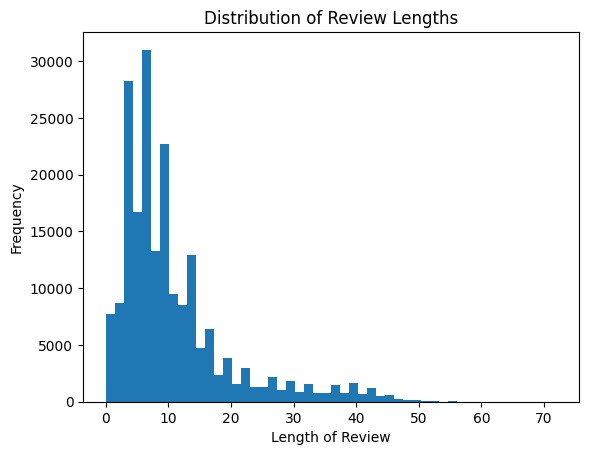

In [30]:
print('리뷰의 최대 길이 : {}'.format(max(len(review) for review in tokenized_data)))
print('리뷰의 평균 길이 : {}'.format(sum(map(len, tokenized_data))/len(tokenized_data)))
plt.hist([len(review) for review in tokenized_data], bins=50)
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.show()

In [31]:
from gensim.models import Word2Vec

model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=5, workers=4, sg=0)

model.wv.vectors.shape

(16477, 100)

In [38]:
print(model.wv.most_similar("최민식"))
print(model.wv.most_similar("히어로"))

[('안성기', 0.8763167858123779), ('한석규', 0.8640945553779602), ('이정재', 0.8459166288375854), ('송강호', 0.8438393473625183), ('정재영', 0.8408186435699463), ('설경구', 0.8407446146011353), ('박신양', 0.8397622108459473), ('이민호', 0.838973343372345), ('이주승', 0.836692750453949), ('김창완', 0.8345715999603271)]
[('무협', 0.8435019254684448), ('느와르', 0.8232187032699585), ('호러', 0.8219498991966248), ('슬래셔', 0.8160237073898315), ('무비', 0.8102420568466187), ('물의', 0.7987841367721558), ('블록버스터', 0.790536642074585), ('블랙', 0.7769455909729004), ('교과서', 0.7732956409454346), ('정통', 0.7727994322776794)]


구글이 제공하는 3M개의 Word2Vec 파라미터를 gensim으로 사용할 수 있다

In [52]:
!ls -lahi /content/drive/MyDrive/ML_Parameters
!cp /content/drive/MyDrive/ML_Parameters/GoogleNews-vectors-negative300.bin.gz ./

total 1.6G
31 -rw------- 1 root root  25M Mar 18 01:16 eng_w2v
35 -r-------- 1 root root 1.6G Sep  4  2016 GoogleNews-vectors-negative300.bin.gz


In [54]:
!ls -alhi

total 1.7G
6684678 drwxr-xr-x 1 root root 4.0K Mar 18 02:22  .
3014678 drwxr-xr-x 1 root root 4.0K Mar 18 01:13  ..
2621447 drwxr-xr-x 4 root root 4.0K Jan 16 14:24  .config
3021150 -rw-r--r-- 1 root root 2.4K Mar 18 02:14 'download?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM&export=download'
      1 drwx------ 5 root root 4.0K Mar 18 01:16  drive
3021148 -rw-r--r-- 1 root root  60K Mar 18 02:13  edit
3021149 -rw-r--r-- 1 root root  60K Mar 18 02:13  edit.1
3020699 -rw-r--r-- 1 root root  25M Mar 18 01:15  eng_w2v
3021217 -r-------- 1 root root 1.6G Mar 18 02:23  GoogleNews-vectors-negative300.bin.gz
3020872 -rw-r--r-- 1 root root  19M Mar 18 01:20  ratings.txt
6684679 drwxr-xr-x 1 root root 4.0K Jan 16 14:24  sample_data
3019919 -rw-r--r-- 1 root root  72M Mar 18 01:14  ted_en-20160408.xml


In [53]:
import gensim
import urllib.request

word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True)

In [57]:
print(word2vec_model.vectors.shape)
print(word2vec_model.similarity("this", "is"))
print(word2vec_model.similarity("post", "book"))
print(word2vec_model['book'])

(3000000, 300)
0.40797037
0.057204384
[ 0.11279297 -0.02612305 -0.04492188  0.06982422  0.140625    0.03039551
 -0.04370117  0.24511719  0.08740234 -0.05053711  0.23144531 -0.07470703
  0.21875     0.03466797 -0.14550781  0.05761719  0.00671387 -0.00701904
  0.13183594 -0.25390625  0.14355469 -0.140625   -0.03564453 -0.21289062
 -0.24804688  0.04980469 -0.09082031  0.14453125  0.05712891 -0.10400391
 -0.19628906 -0.20507812 -0.27539062  0.03063965  0.20117188  0.17382812
  0.09130859 -0.10107422  0.22851562 -0.04077148  0.02709961 -0.00106049
  0.02709961  0.34179688 -0.13183594 -0.078125    0.02197266 -0.18847656
 -0.17480469 -0.05566406 -0.20898438  0.04858398 -0.07617188 -0.15625
 -0.05419922  0.01672363 -0.02722168 -0.11132812 -0.03588867 -0.18359375
  0.28710938  0.01757812  0.02185059 -0.05664062 -0.01251221  0.01708984
 -0.21777344 -0.06787109  0.04711914 -0.00668335  0.08544922 -0.02209473
  0.31835938  0.01794434 -0.02246094 -0.03051758 -0.09570312  0.24414062
  0.20507812  0.